Loading required modules

In [1]:
#required modules

#data manipulation
import pandas as pd

#visualization
import seaborn as sns
import matplotlib.pyplot as plt

#clustering models
from sklearn.cluster import KMeans, DBSCAN

#cluster evaluation
from sklearn.metrics import calinski_harabasz_score, silhouette_score

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Loading data

In [4]:
df_blob = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/blob.csv")
df_dart = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dart.csv")
df_outliers = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/outliers.csv")

In [5]:
df_blob.head()

,x,y,color
0,199.115034,72.641121,1
1,196.880523,247.744708,2
2,88.426271,233.962425,2
3,118.578789,264.044188,2
4,249.572490,260.896521,0


In [6]:
df_dart.head()

,x,y,color
0,239.650438,300.176323,0
1,288.373881,102.813599,0
2,334.129409,165.764844,1
3,193.401962,202.979989,0
4,294.588391,98.569759,0


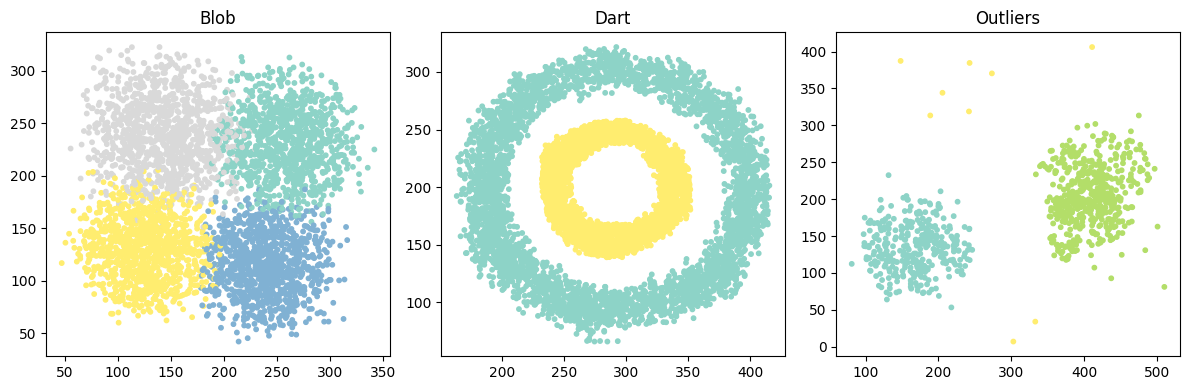

In [8]:
#visualize the datasets

#plot 3 charts in a single row
fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 4))

#blob data in column 1
axes[0].scatter(df_blob['x'], df_blob['y'], c = df_blob['color'], s = 10, cmap = "Set3")
axes[0].set_title("Blob");

#dart data in column 2
axes[1].scatter(df_dart['x'], df_dart['y'], c = df_dart['color'], s = 10, cmap = "Set3")
axes[1].set_title("Dart");

#outlier data in column 3
axes[2].scatter(df_outliers['x'], df_outliers['y'], c = df_outliers['color'], s = 10, cmap = "Set3")
axes[2].set_title("Outliers");

plt.tight_layout()
plt.show()

/tmp/ipykernel_4046/661168743.py:7: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axes[0].scatter(df_blob['x'], df_blob['y'], s = 10, cmap = "Set3")
/tmp/ipykernel_4046/661168743.py:11: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axes[1].scatter(df_dart['x'], df_dart['y'], s = 10, cmap = "Set3")
/tmp/ipykernel_4046/661168743.py:15: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axes[2].scatter(df_outliers['x'], df_outliers['y'], s = 10, cmap = "Set3")


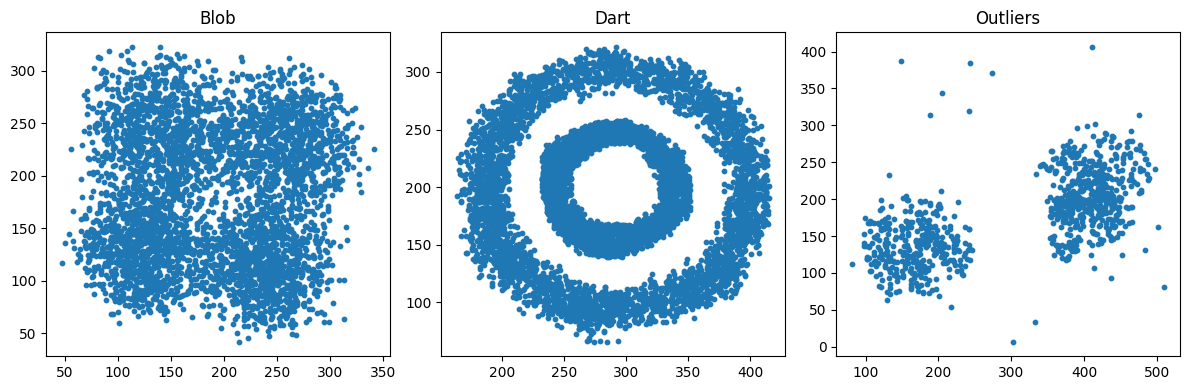

In [9]:
#visualize the datasets

#plot 3 charts in a single row
fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 4))

#blob data in column 1
axes[0].scatter(df_blob['x'], df_blob['y'], s = 10, cmap = "Set3")
axes[0].set_title("Blob");

#dart data in column 2
axes[1].scatter(df_dart['x'], df_dart['y'], s = 10, cmap = "Set3")
axes[1].set_title("Dart");

#outlier data in column 3
axes[2].scatter(df_outliers['x'], df_outliers['y'], s = 10, cmap = "Set3")
axes[2].set_title("Outliers");

plt.tight_layout()
plt.show()

**K-Means vs DBSCAN (Blob data)**

In [10]:
#prepare data
df_blob_train = df_blob.drop(columns = ['color'])

In [12]:
#initialize kmeans model
df_blob_kmeans = KMeans(n_clusters = 4, init = 'k-means++', random_state = 42)

#train
kmeans_clusters = df_blob_kmeans.fit_predict(df_blob_train)

In [13]:
#initialize dbscan model
df_blob_dbscan = DBSCAN(eps = 13, min_samples = 45, metric = 'euclidean')

#train
dbscan_clusters = df_blob_dbscan.fit_predict(df_blob_train)

In [14]:
df_blob_train['kmeans_clusters'] = kmeans_clusters
df_blob_train['dbscan_clusters'] = dbscan_clusters

/tmp/ipykernel_4046/2286675692.py:7: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axes[0].scatter(df_blob['x'], df_blob['y'], s = 10, cmap = "Set3")


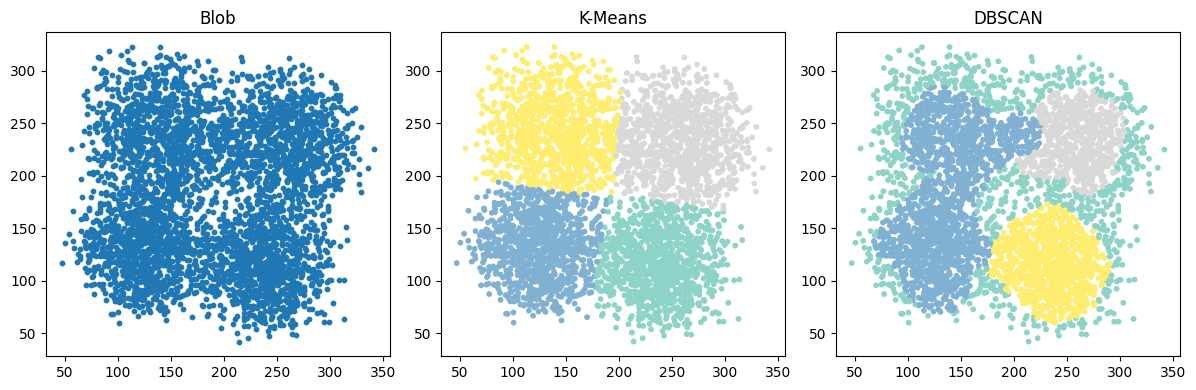

In [15]:
#visualize the clusters

#plot 3 charts in a single row
fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 4))

#original data in column 1
axes[0].scatter(df_blob['x'], df_blob['y'], s = 10, cmap = "Set3")
axes[0].set_title("Blob");

#kmeans clusters in column 2
axes[1].scatter(df_blob_train['x'], df_blob_train['y'], c = df_blob_train['kmeans_clusters'], s = 10, cmap = "Set3")
axes[1].set_title("K-Means");

#dbscan clusters in column 3
axes[2].scatter(df_blob_train['x'], df_blob_train['y'], c = df_blob_train['dbscan_clusters'], s = 10, cmap = "Set3")
axes[2].set_title("DBSCAN");

plt.tight_layout()
plt.show()

**K-Means v/s DBSCAN (Dart data)**

In [16]:
#prepare data
df_dart_train = df_dart.drop(columns = ['color'])

In [17]:
#initialize kmeans model
df_dart_kmeans = KMeans(n_clusters = 2, init = 'k-means++', random_state = 42)

#train
kmeans_clusters = df_dart_kmeans.fit_predict(df_dart_train)

In [18]:
#initialize dbscan model
df_dart_dbscan = DBSCAN(eps = 8, min_samples = 4, metric = 'euclidean')

#train
dbscan_clusters = df_dart_dbscan.fit_predict(df_dart_train)

In [19]:
df_dart_train['kmeans_clusters'] = kmeans_clusters
df_dart_train['dbscan_clusters'] = dbscan_clusters

/tmp/ipykernel_4046/2115955233.py:7: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axes[0].scatter(df_dart['x'], df_dart['y'], s = 10, cmap = "Set3")


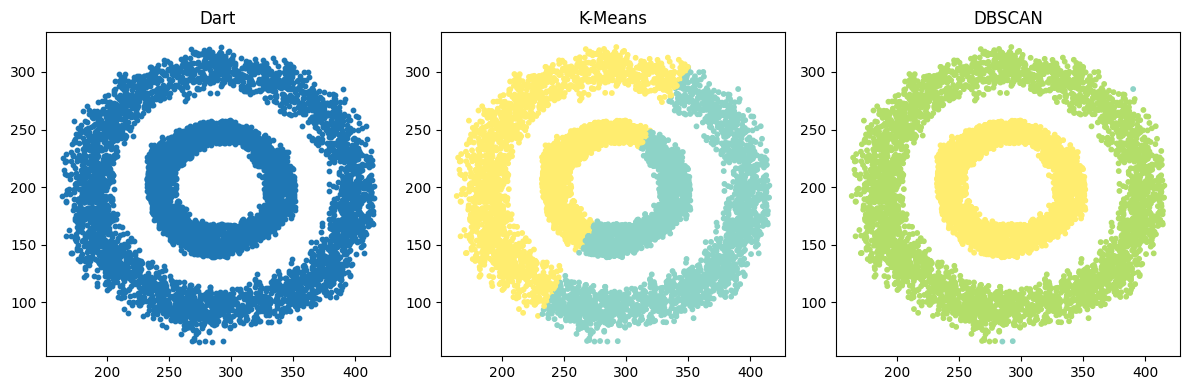

In [20]:
#visualize the clusters

#plot 3 charts in a single row
fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 4))

#original data in column 1
axes[0].scatter(df_dart['x'], df_dart['y'], s = 10, cmap = "Set3")
axes[0].set_title("Dart");

#kmeans clusters in column 2
axes[1].scatter(df_dart_train['x'], df_dart_train['y'], c = df_dart_train['kmeans_clusters'], s = 10, cmap = "Set3")
axes[1].set_title("K-Means");

#dbscan clusters in column 3
axes[2].scatter(df_dart_train['x'], df_dart_train['y'], c = df_dart_train['dbscan_clusters'], s = 10, cmap = "Set3")
axes[2].set_title("DBSCAN");

plt.tight_layout()
plt.show()

**K-Means v/s DBSCAN (Outliers data)**

In [21]:
#prepare data
df_outliers_train = df_outliers.drop(columns = ['color'])

In [22]:
#initialize kmeans model
df_outliers_kmeans = KMeans(n_clusters = 3, init = 'k-means++', random_state = 42)

#train
kmeans_clusters = df_outliers_kmeans.fit_predict(df_outliers_train)

In [23]:
#initialize dbscan model
df_outliers_dbscan = DBSCAN(eps = 10, min_samples = 4, metric = 'euclidean')

#train
dbscan_clusters = df_outliers_dbscan.fit_predict(df_outliers_train)

In [24]:
df_outliers_train['kmeans_clusters'] = kmeans_clusters
df_outliers_train['dbscan_clusters'] = dbscan_clusters

/tmp/ipykernel_4046/289460384.py:7: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axes[0].scatter(df_outliers['x'], df_outliers['y'], s = 10, cmap = "Set3")


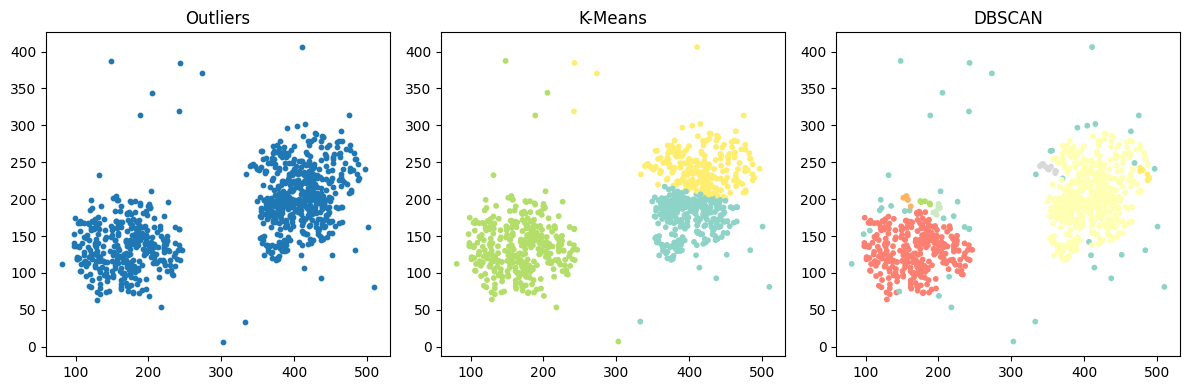

In [25]:
#visualize the clusters

#plot 3 charts in a single row
fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 4))

#original data in column 1
axes[0].scatter(df_outliers['x'], df_outliers['y'], s = 10, cmap = "Set3")
axes[0].set_title("Outliers");

#kmeans clusters in column 2
axes[1].scatter(df_outliers_train['x'], df_outliers_train['y'], c = df_outliers_train['kmeans_clusters'], s = 10, cmap = "Set3")
axes[1].set_title("K-Means");

#dbscan clusters in column 3
axes[2].scatter(df_outliers_train['x'], df_outliers_train['y'], c = df_outliers_train['dbscan_clusters'], s = 10, cmap = "Set3")
axes[2].set_title("DBSCAN");

plt.tight_layout()
plt.show()

## Clusters evaluation

In [26]:
kmean_ch = calinski_harabasz_score(df_blob.drop(columns = ['color']), df_blob_train['kmeans_clusters'])
dbscan_ch = calinski_harabasz_score(df_blob.drop(columns = ['color']), df_blob_train['dbscan_clusters'])

print(f"[K-Means] CH Score for Blob data: {kmean_ch}")
print(f"[DBSCAN] CH Score for Blob data: {dbscan_ch}")

[K-Means] CH Score for Blob data: 5086.638286689799
[DBSCAN] CH Score for Blob data: 1073.8424437930075


In [27]:
kmean_ch = silhouette_score(df_blob.drop(columns = ['color']), df_blob_train['kmeans_clusters'])
dbscan_ch = silhouette_score(df_blob.drop(columns = ['color']), df_blob_train['dbscan_clusters'])

print(f"[K-Means] Silhouette Score for Blob data: {kmean_ch}")
print(f"[DBSCAN] Silhouette Score for Blob data: {dbscan_ch}")

[K-Means] Silhouette Score for Blob data: 0.4720518917836792
[DBSCAN] Silhouette Score for Blob data: 0.24657600475335453


### Customer Segmentation Using K-Means Clustering

In [28]:
#Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs

#synthetic clustering data
np.random.seed(42)
data = pd.DataFrame({
    'age': np.random.randint(18, 60, 200),
    'income': np.random.normal(50, 15, 200),
    'spending_score': np.random.uniform(10, 100, 200),
    'visits_per_month': np.random.randint(1, 10, 200)
})

data.head()

,age,income,spending_score,visits_per_month
0,56,37.972582,77.713708,1
1,46,70.760236,81.242114,3
2,32,71.078080,81.065633,4
3,25,70.884886,18.208549,8
4,38,36.790388,54.497827,6


In [29]:
features = ['age', 'income', 'spending_score', 'visits_per_month']
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data[features])

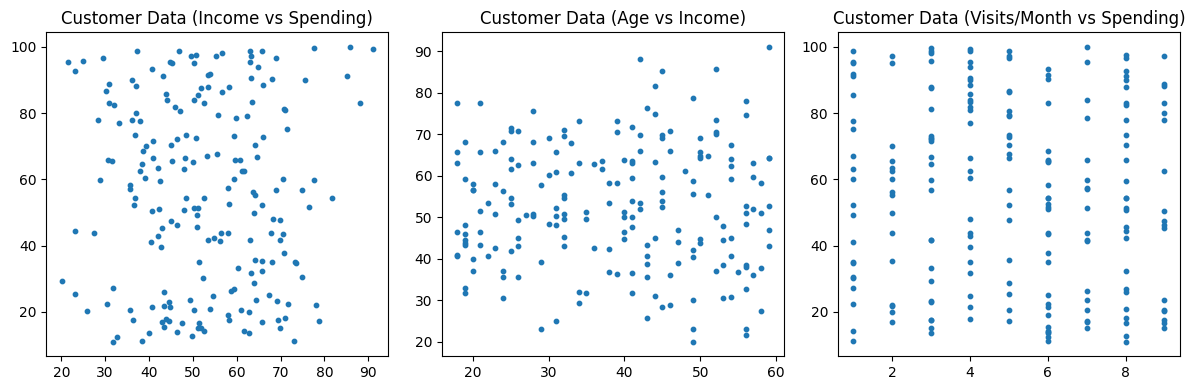

In [32]:
#visualize the dataset

#plot 3 charts in a single row
fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 4))

axes[0].scatter(data['income'], data['spending_score'], s = 10)
axes[0].set_title("Customer Data (Income vs Spending)");

axes[1].scatter(data['age'], data['income'], s = 10)
axes[1].set_title("Customer Data (Age vs Income)");

axes[2].scatter(data['visits_per_month'], data['spending_score'], s = 10)
axes[2].set_title("Customer Data (Visits/Month vs Spending)");

plt.tight_layout()
plt.show()

In [37]:
#initialize kmeans model
data_kmeans = KMeans(n_clusters = 4, init = 'k-means++', random_state = 42)

#train
kmeans_clusters = data_kmeans.fit_predict(data)

In [38]:
data['kmeans_clusters'] = kmeans_clusters

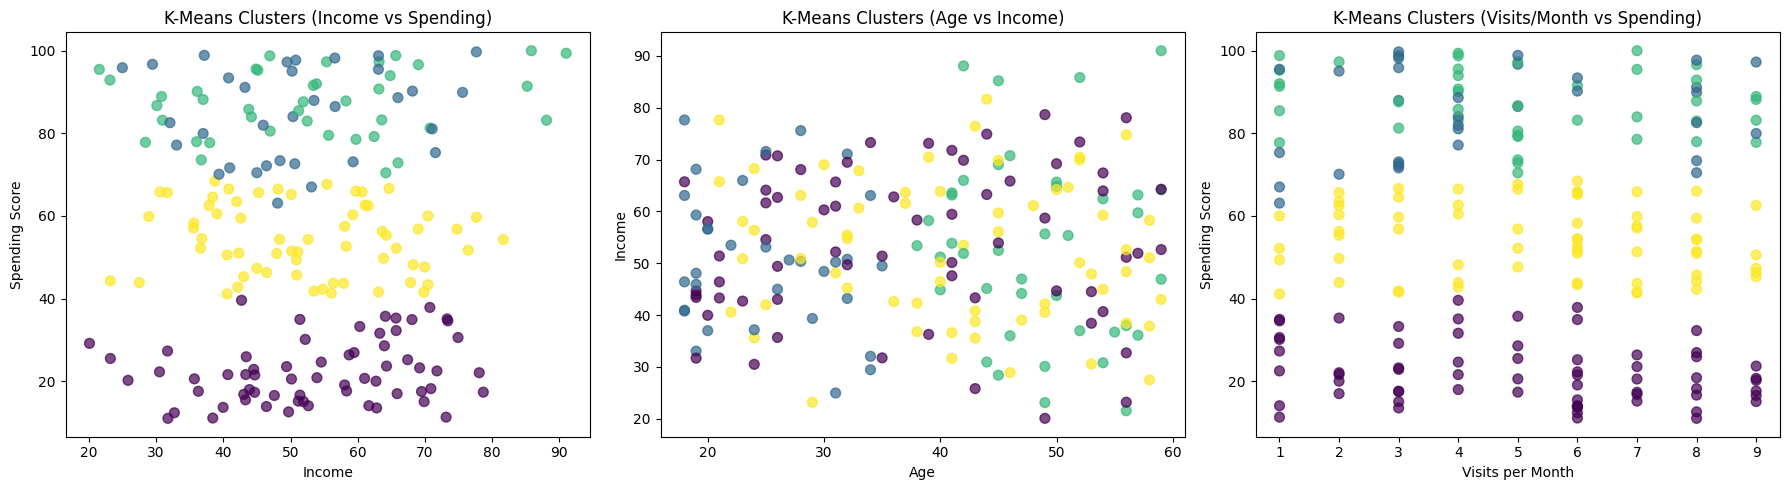

In [41]:

fig_clusters, axes_clusters = plt.subplots(nrows = 1, ncols = 3, figsize = (18, 5))

#K-Means clusters for Income vs Spending Score
axes_clusters[0].scatter(data['income'], data['spending_score'], c = data['kmeans_clusters'], s = 50, cmap = "viridis", alpha=0.7)
axes_clusters[0].set_title("K-Means Clusters (Income vs Spending)")
axes_clusters[0].set_xlabel("Income")
axes_clusters[0].set_ylabel("Spending Score")

#K-Means clusters for Age vs Income
axes_clusters[1].scatter(data['age'], data['income'], c = data['kmeans_clusters'], s = 50, cmap = "viridis", alpha=0.7)
axes_clusters[1].set_title("K-Means Clusters (Age vs Income)")
axes_clusters[1].set_xlabel("Age")
axes_clusters[1].set_ylabel("Income")

#K-Means clusters for Visits per Month vs Spending Score
axes_clusters[2].scatter(data['visits_per_month'], data['spending_score'], c = data['kmeans_clusters'], s = 50, cmap = "viridis", alpha=0.7)
axes_clusters[2].set_title("K-Means Clusters (Visits/Month vs Spending)")
axes_clusters[2].set_xlabel("Visits per Month")
axes_clusters[2].set_ylabel("Spending Score")

plt.tight_layout()
plt.show()